In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [18]:
sentiment = pd.read_csv("csv_files/fear_greed_index.csv")
trader = pd.read_csv("csv_files/historical_data.csv")

In [19]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
print(trader.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

# Normalize column names (lowercase, remove spaces)

In [21]:
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace(r'[^0-9a-z_]', '', regex=True)
    )
    return df


In [22]:
sentiment = normalize_cols(sentiment)

print("Sentiment columns:", sentiment.columns.tolist())


Sentiment columns: ['timestamp', 'value', 'classification', 'date']


In [23]:
trader = normalize_cols(trader)

print("Trader columns:", trader.columns.tolist()[:10])

Trader columns: ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl']


# Prepare the sentiment dataset

In [24]:
# Convert 'date' column to datetime format
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Keep only the useful columns
sentiment = sentiment[['date', 'classification']].dropna(subset=['date'])

display(sentiment.head())

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


#  Prepare the trader dataset

In [25]:
# Convert 'timestamp_ist' to datetime
trader['timestamp_ist'] = pd.to_datetime(trader['timestamp_ist'], dayfirst=True, errors='coerce')

# Create a new 'date' column for merging
trader['date'] = trader['timestamp_ist'].dt.date
trader['date'] = pd.to_datetime(trader['date'])

# Convert key numeric columns
for col in ['closed_pnl', 'execution_price', 'size_usd', 'size_tokens']:
    trader[col] = pd.to_numeric(trader[col], errors='coerce')

# Create total trading volume column
trader['total_volume'] = trader['size_usd'].fillna(trader['execution_price'] * trader['size_tokens'])

# Add a profit flag (1 if profit, 0 if loss)
trader['profitable'] = np.where(trader['closed_pnl'] > 0, 1, 0)


display(trader[['account', 'coin', 'closed_pnl', 'execution_price', 'total_volume', 'profitable', 'date']].head())


,account,coin,closed_pnl,execution_price,total_volume,profitable,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,7.9769,7872.16,0,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,7.9800,127.68,0,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,7.9855,1150.63,0,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,7.9874,1142.04,0,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,7.9894,69.75,0,2024-12-02



# Merge both datasets on 'date'


In [26]:
merged_df = pd.merge(trader, sentiment, on='date', how='left')

print("Merged shape:", merged_df.shape)
display(merged_df.head())

Merged shape: (211224, 20)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,total_volume,profitable,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,7872.16,0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,127.68,0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1150.63,0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1142.04,0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,69.75,0,Extreme Greed


In [27]:
# Save the merged dataset
merged_df.to_csv("csv_files/merged_trader_sentiment.csv", index=False)


In [ ]:
sentiment.to_csv("csv_files/cleaned_sentiment.csv", index=False)
trader.to_csv("csv_files/cleaned_trader.csv", index=False)

# Overview of the Merged Dataset

In [29]:
print("Dataset Overview:")
print("Rows:", merged_df.shape[0])
print("Columns:", merged_df.shape[1])
print("\nMissing values per column:\n")
print(merged_df.isnull().sum())

# Show numeric summary
display(merged_df.describe())


Dataset Overview:
Rows: 211224
Columns: 20

Missing values per column:

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
total_volume        0
profitable          0
classification      6
dtype: int64


,execution_price,size_tokens,size_usd,timestamp_ist,start_position,closed_pnl,order_id,fee,trade_id,timestamp,date,total_volume,profitable
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,2025-01-30 23:54:28.674013952,5.639451e+03,0.411265
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00,0.000000e+00,0.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00,1.937900e+02,0.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,2025-02-24 00:00:00,5.970450e+02,0.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,2025-04-02 00:00:00,2.058960e+03,1.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00,3.921431e+06,1.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,NaN,3.657514e+04,0.492064


# Visualization

###  Average Trader Profit vs Market Sentiment

/var/folders/s5/b590b0mj47v0frhj95y4k2th0000gn/T/ipykernel_82452/2369328698.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='closed_pnl', palette='viridis')


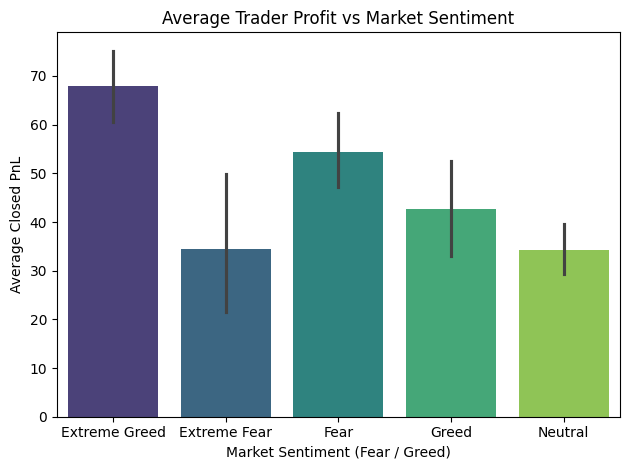

In [30]:
sns.barplot(data=merged_df, x='classification', y='closed_pnl', palette='viridis')
plt.title("Average Trader Profit vs Market Sentiment")
plt.xlabel("Market Sentiment (Fear / Greed)")
plt.ylabel("Average Closed PnL")
plt.tight_layout()

# Save to outputs folder
plt.savefig("outputs/avg_profit_vs_sentiment.png")
plt.show()


### Average Trade Volume vs Market Sentiment

/var/folders/s5/b590b0mj47v0frhj95y4k2th0000gn/T/ipykernel_82452/4098800214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_vol, x='classification', y='total_volume', palette='magma')


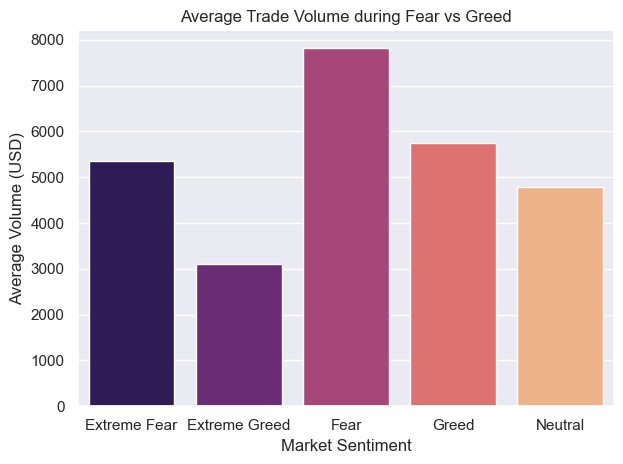

In [36]:
avg_vol = merged_df.groupby('classification')['total_volume'].mean().reset_index()

sns.barplot(data=avg_vol, x='classification', y='total_volume', palette='magma')
plt.title("Average Trade Volume during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Volume (USD)")
plt.tight_layout()


plt.savefig("outputs/avg_volume_vs_sentiment.png")
plt.show()


### Profit Distribution (Fear vs Greed)

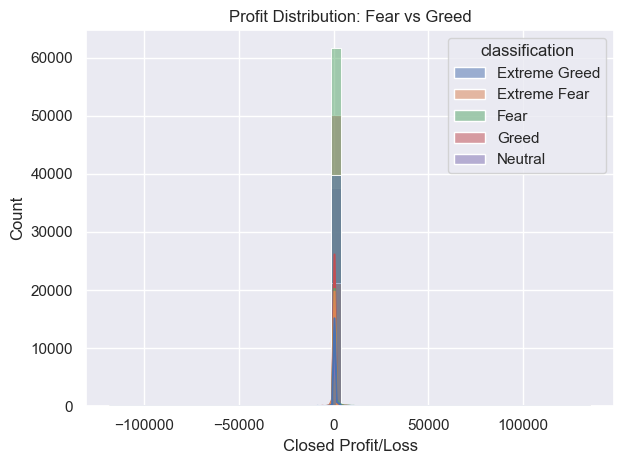

In [37]:
sns.histplot(data=merged_df, x='closed_pnl', hue='classification', bins=50, kde=True)
plt.title("Profit Distribution: Fear vs Greed")
plt.xlabel("Closed Profit/Loss")
plt.tight_layout()

plt.savefig("outputs/profit_distribution.png")
plt.show()

### Top 10 Traders by Profit

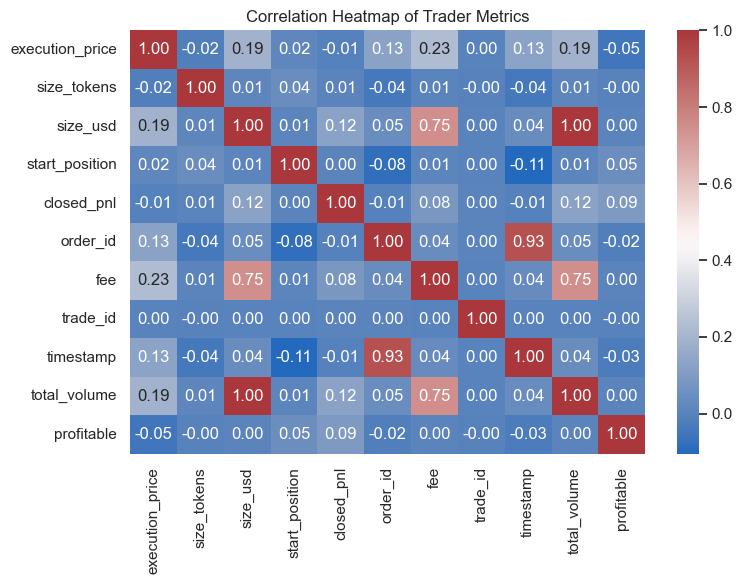

In [38]:
numeric_df = merged_df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="vlag")
plt.title("Correlation Heatmap of Trader Metrics")
plt.tight_layout()

plt.savefig("outputs/correlation_heatmap.png")
plt.show()